In [33]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

## Step up response

In [34]:
l_files1 = glob.glob("..\\output\\simulation_results\\step_up_voltage_dist_response\\*.csv")

In [35]:
df1 = pd.read_csv(l_files1[1], index_col=0)
df1.tail()

,Idc,Pac,Vdc_ref,Vdc
TIME,,,,
4.9996,0.307116,199.935516,652.8,651.301596
4.9997,0.307031,199.935281,652.8,651.295580
4.9998,0.306948,199.937825,652.8,651.289838
4.9999,0.306866,199.937708,652.8,651.283931
5.0000,0.306785,199.935150,652.8,651.276380


In [36]:
def analyse_step_response(res_file: str, pref: float):
    
    p_df = pd.read_csv(res_file, index_col=0)

    # Extract parameters from filename
    filename = os.path.basename(res_file)
    p_df["R_ohms"] = float(filename.split("_")[-2][1:])
    p_df["H_mH"] = float(filename.split("_")[-3][1:])

    # Power column (3rd column)
    pac_col = p_df.iloc[:, 1]

    # Start searching after step (sample 30000)
    search_region = pac_col.iloc[30000:]

    # Find first index where threshold is reached
    p50_index = search_region[search_region >= 0.5 * pref].index[0]
    p90_index = search_region[search_region >= 0.9 * pref].index[0]

    # Convert to time (assuming sample index = time in ms or adjust if needed)
    t50 = np.round(p50_index - 3., 3)
    t90 = np.round(p90_index - 3., 3)

    return t50, t90, p50_index, p90_index, p_df

In [37]:
t50, t90, p50_index, p90_index, res_df = analyse_step_response(files[1], 200)

In [38]:
t50, t90

(0.013, 0.045)

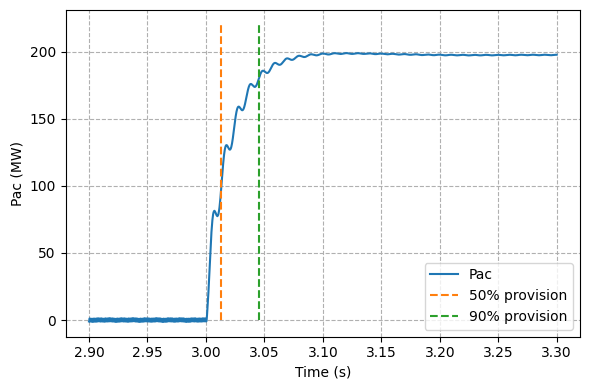

In [39]:
fig, ax = plt.subplots(figsize=(6, 4))
df = df1.copy()
df.iloc[29000:33000]['Pac'].plot(ax=ax, label="Pac")
ax.plot([p50_index, p50_index], [0,220], linestyle='--', label="50% provision")
ax.plot([p90_index, p90_index], [0,220], linestyle='--', label="90% provision")
# ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_ylabel("Pac (MW)")
ax.set_xlabel("Time (s)")
plt.grid(linestyle="--")
plt.legend(loc=4)
plt.tight_layout()
# plt.savefig("step_up_u_dist.jpg")


### Run test

In [41]:
csv_files = glob.glob("..\\output\\simulation_results\\step_up_voltage_dist_response\\*.csv")
pref = 200
result_summary = []
for file in csv_files:
    file_df = pd.read_csv(file, index_col=0)
    test_var = 1
    try:
        t50, t90, p50_index, p90_index, result_df = analyse_step_response(files[1], pref)
    except IndexError:
        print(file)
        continue
    if t50 > 0.05:
        test_var = 0
    elif t90 > 0.3:
        test_var = 0
    result_df["t50"] = t50
    result_df["t90"] = t90
    result_df["score"] = test_var
    result_summary.append(pd.DataFrame([result_df.iloc[-1,:]]))
result_summary_df1 = pd.concat(result_summary, axis=0).reset_index(drop=True)
result_summary_df1.rename(columns={"Idc": "Idc_final", "Pac": "Pac_final", "Vdc": "Vdc_final"}, inplace=True)

output_file = Path("summary\\step_up_u_dist_response_summary.csv")
output_file.parent.mkdir(parents=True, exist_ok=True)
result_summary_df1.to_csv(output_file , index=True)

In [42]:
result_summary_df1.head()

,Idc_final,Pac_final,Vdc_ref,Vdc_final,R_ohms,H_mH,t50,t90,score
0,0.318702,199.935448,627.2,625.597487,6.0,400.0,0.013,0.045,1.0
1,0.318702,199.935448,627.2,625.597487,6.0,400.0,0.013,0.045,1.0
2,0.318702,199.935448,627.2,625.597487,6.0,400.0,0.013,0.045,1.0
3,0.318702,199.935448,627.2,625.597487,6.0,400.0,0.013,0.045,1.0
4,0.318702,199.935448,627.2,625.597487,6.0,400.0,0.013,0.045,1.0


In [43]:
result_summary_df1[result_summary_df1['score']==1].shape

(45, 9)

In [44]:
result_summary_df1.shape

(45, 9)

## Analyse step down response

In [45]:
l_files2 = glob.glob("..\\output\\simulation_results\\step_down_voltage_dist_response\\*.csv")

In [46]:
df2 = pd.read_csv(l_files2[1], index_col=0)
df2.tail()

,Idc,Pac,Vdc_ref,Vdc
TIME,,,,
4.9996,0.319026,199.943006,627.2,625.625800
4.9997,0.318942,199.942923,627.2,625.619421
4.9998,0.318860,199.941093,627.2,625.612678
4.9999,0.318780,199.938260,627.2,625.605306
5.0000,0.318702,199.935448,627.2,625.597487


In [47]:
t50, t90, p50_index, p90_index, res_df = analyse_step_response(l_files[1], 200)

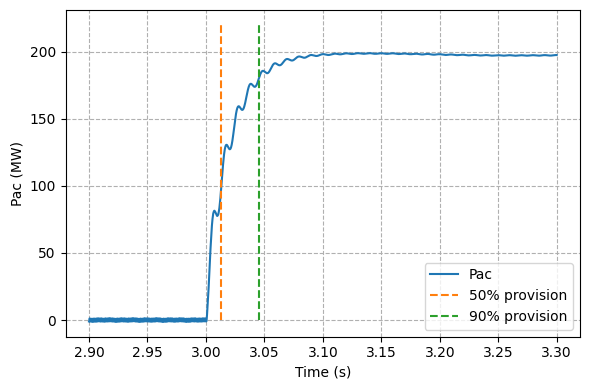

In [48]:
fig, ax = plt.subplots(figsize=(6, 4))
df = df2.copy()
df.iloc[29000:33000]['Pac'].plot(ax=ax, label="Pac")
ax.plot([p50_index, p50_index], [0,220], linestyle='--', label="50% provision")
ax.plot([p90_index, p90_index], [0,220], linestyle='--', label="90% provision")
# ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
ax.set_ylabel("Pac (MW)")
ax.set_xlabel("Time (s)")
plt.grid(linestyle="--")
plt.legend(loc=4)
plt.tight_layout()
# plt.savefig("step_down_u_dist.jpg")

In [49]:
csv_files = files
pref = 200
result_summary = []
for file in csv_files:
    file_df = pd.read_csv(file, index_col=0)
    test_var = 1
    try:
        t50, t90, p50_index, p90_index, result_df = analyse_step_response(files[1], pref)
    except IndexError:
        print(file)
        continue
    if t50 > 0.05:
        test_var = 0
    elif t90 > 0.3:
        test_var = 0
    result_df["t50"] = t50
    result_df["t90"] = t90
    result_df["score"] = test_var
    result_summary.append(pd.DataFrame([result_df.iloc[-1,:]]))
result_summary_df2 = pd.concat(result_summary, axis=0).reset_index(drop=True)
result_summary_df2.rename(columns={"Idc": "Idc_final", "Pac": "Pac_final", "Vdc": "Vdc_final"}, inplace=True)

output_file = Path("summary\\step_down_u_dist_response_summary.csv")
output_file.parent.mkdir(parents=True, exist_ok=True)
result_summary_df2.to_csv(output_file , index=True)

In [50]:
result_summary_df2.head()

,Idc_final,Pac_final,Vdc_ref,Vdc_final,R_ohms,H_mH,t50,t90,score
0,0.318702,199.935448,627.2,625.597487,6.0,400.0,0.013,0.045,1.0
1,0.318702,199.935448,627.2,625.597487,6.0,400.0,0.013,0.045,1.0
2,0.318702,199.935448,627.2,625.597487,6.0,400.0,0.013,0.045,1.0
3,0.318702,199.935448,627.2,625.597487,6.0,400.0,0.013,0.045,1.0
4,0.318702,199.935448,627.2,625.597487,6.0,400.0,0.013,0.045,1.0


In [51]:
result_summary_df2[result_summary_df2['score']==1].shape

(45, 9)

## Visualisation summary

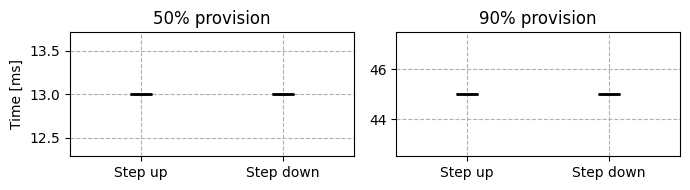

In [59]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 2))

# ---------------- t50 ----------------
bp1 = ax1.boxplot(
    [result_summary_df1["t50"]*1000, result_summary_df2["t50"]*1000],
    tick_labels=["Step up", "Step down"],
    patch_artist=True
)

colors = ["skyblue", "salmon"]
for box, color in zip(bp1["boxes"], colors):
    box.set(facecolor=color)

for median in bp1["medians"]:
    median.set(color="black", linewidth=2)

ax1.set_ylabel("Time [ms]")
ax1.set_title("50% provision")
ax1.grid(linestyle="--")

# ---------------- t90 ----------------
bp2 = ax2.boxplot(
    [result_summary_df1["t90"]*1000, result_summary_df2["t90"]*1000],
    tick_labels=["Step up", "Step down"],
    patch_artist=True
)

for box, color in zip(bp2["boxes"], colors):
    box.set(facecolor=color)

for median in bp2["medians"]:
    median.set(color="black", linewidth=2)

ax2.set_title("90% provision")
ax2.grid(linestyle="--")

plt.tight_layout()

output_file = Path("summary\\step_voltage_dist_plot.pdf")
output_file.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(output_file)